# <font color= #003366> **Análisis de Sentimiento** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 2: </Strong>  <font color="blue">`GANs` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

## <font color=  #003366> **Introducción**</font>

En este notebook se desarrolló un sistema de análisis de reseñas utilizando técnicas de Deep Learning y procesamiento de lenguaje natural (NLP) basadas en transformers. Para ello se realizó el fine-tuning del modelo BERT usando el dataset de reseñas de Amazon, con el objetivo de clasificar opiniones positivas y negativas.

Además de la clasificación general de sentimiento, se implementó un análisis por aspectos para identificar opiniones relacionadas con calidad, precio y envío dentro de cada reseña. También se incorporó un nivel de confianza en las predicciones mediante calibración de probabilidades, permitiendo interpretar qué tan segura es cada clasificación realizada por el modelo. Finalmente, se evaluó el desempeño utilizando métricas como accuracy y F1-score, junto con visualizaciones para analizar el comportamiento del modelo durante el entrenamiento.

## <font color=  #003366> **Librerías**</font>

In [1]:
!pip uninstall -y transformers accelerate datasets peft

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1


In [2]:
!pip install transformers==4.41.2
!pip install accelerate==0.31.0
!pip install datasets==2.19.1
!pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 71.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires datasets, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━

In [3]:
import pandas as pd
from datasets import Dataset, load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import numpy as np
from collections import defaultdict
from transformers import EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

## <font color=  #003366> **Dataset**</font>

In [4]:
dataset = load_dataset("amazon_polarity")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

In [5]:
print(dataset)
print(dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})
{'label': 1, 'title': 'Stuning even for the non-gamer', 'content': 'This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'}


In [6]:
df_train = dataset['train'].shuffle(seed=42).select(range(10000))
df_test = dataset['test'].shuffle(seed=42).select(range(2000))

In [7]:
df_train.to_pandas()['label'].value_counts()

,count
label,
0,5003
1,4997


In [8]:
df_test.to_pandas()['label'].value_counts()

,count
label,
1,1018
0,982


In [9]:
df_train = df_train.rename_column("label", "labels")
df_test = df_test.rename_column("label", "labels")

In [10]:
split = df_train.train_test_split(test_size=0.2, seed=42)

df_train = split["train"]
df_val = split["test"]

In [11]:
def combinar(example):
    return {
        "text": example["title"] + " " + example["content"]
    }

df_train = df_train.map(combinar)
df_test = df_test.map(combinar)
df_val = df_val.map(combinar)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Para el desarrollo del proyecto se utilizó una muestra del dataset original de Amazon Polarity con el fin de reducir el tiempo de entrenamiento y facilitar las pruebas del modelo. Se seleccionaron 5000 reseñas para entrenamiento y 1000 reseñas para prueba, mezclando previamente los datos de manera aleatoria para evitar sesgos. Posteriormente, se combinaron las columnas de título y contenido de cada reseña en un solo texto, el cual fue utilizado como entrada para el modelo de procesamiento de lenguaje natural.

In [12]:
df_train = df_train.remove_columns(["title", "content"])
df_test = df_test.remove_columns(["title", "content"])
df_val = df_val.remove_columns(["title", "content"])

## <font color=  #003366> **Tokenización**</font>

In [13]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)

df_train = df_train.map(tokenize, batched=True)
df_test = df_test.map(tokenize, batched=True)
df_val = df_val.map(tokenize, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

se carga el tokenizer del modelo BERT, el cual convierte el texto de las reseñas en números que el modelo puede entender. Después se tokenizan las reseñas del conjunto de entrenamiento y prueba, limitar¿ndo los textos a un máximo de 128 tokens y padding para que todas las entradas tengan el mismo tamaño. Esto permite que los datos puedan ser procesados correctamente durante el entrenamiento del modelo.

## <font color=  #003366> **Modelo**</font>

In [14]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2, hidden_dropout_prob=0.3, attention_probs_dropout_prob=0.3)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Se carga el modelo preentrenado BERT para realizar la clasificación de texto. Se utilizó la versión bert-base-uncased y se configuró para trabajar con dos clases, correspondientes a sentimientos positivos y negativos. Al utilizar un modelo preentrenado, el entrenamiento aprovecha el conocimiento previo adquirido por BERT sobre el lenguaje, permitiendo obtener mejores resultados en el análisis de reseñas.

## <font color=  #003366> **Entrenamiento**</font>

In [15]:
from transformers import EarlyStoppingCallback
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=6,
    learning_rate=5e-6,
    weight_decay=0.01,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    evaluation_strategy="epoch",

    save_strategy="epoch",
    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_dir="./logs",
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=df_train,
    eval_dataset=df_val,
    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.303900,0.264609,0.924500,0.925136,0.910244,0.940524
2,0.293000,0.268990,0.930000,0.929150,0.932927,0.925403
3,0.236200,0.286936,0.933500,0.933467,0.926514,0.940524
4,0.215300,0.304204,0.938500,0.939139,0.922255,0.956653
5,0.212100,0.286606,0.939000,0.939000,0.931548,0.946573


TrainOutput(global_step=5000, training_loss=0.26920300750732423, metrics={'train_runtime': 1321.8434, 'train_samples_per_second': 36.313, 'train_steps_per_second': 4.539, 'total_flos': 2631110553600000.0, 'train_loss': 0.26920300750732423, 'epoch': 5.0})

Se configuró el proceso de entrenamiento del modelo BERT usando fine tuning para mejorar su desempeño al hacer la clasificación de sentimientos. Se establecieron parámetros como un learning rate bajo, weight decay para reducir el sobreajuste y un mayor número de épocas para permitir un aprendizaje más completo.

Además, se utilizó validación por época para monitorear el rendimiento del modelo durante el entrenamiento y se seleccionó el mejor modelo con base en el F1-score, que es una métrica más robusta para problemas de clasificación. También se incorporó early stopping, lo que permite detener el entrenamiento automáticamente si el desempeño no mejora, evitando así un sobreajuste innecesario y optimizando el proceso de entrenamiento.

## <font color=  #003366> **Visualización de pérdidas**</font>

In [16]:
logs = trainer.state.log_history

train_loss = []
eval_loss = []
epochs = []

for log in logs:
    if "eval_loss" in log:
        epochs.append(log["epoch"])
        eval_loss.append(log["eval_loss"])

    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])

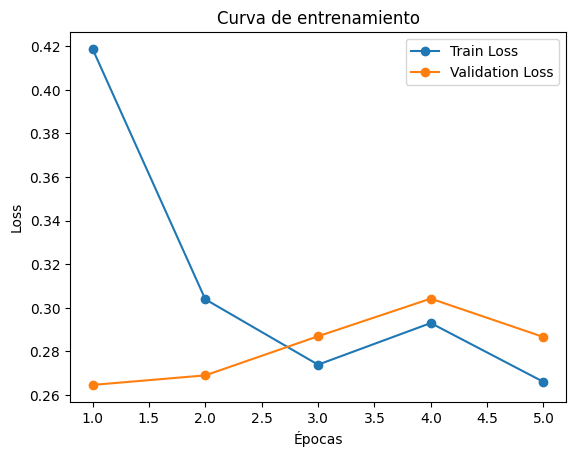

In [17]:
plt.plot(epochs, train_loss[:len(epochs)], marker='o', label="Train Loss")
plt.plot(epochs, eval_loss, marker='o', label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento")
plt.legend()

plt.show()

## <font color=  #003366> **Predicción**</font>

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predecir_sentimiento(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    logits = outputs.logits
    temperature = 2.5
    probs = F.softmax(logits / temperature, dim=1)
    pred = torch.argmax(logits, dim=1).item()
    confianza = probs.max().item()

    sentimiento = "positivo" if pred == 1 else "negativo"

    return sentimiento, confianza

Se creó una función para redecir el sentimiento de una reseña utilizando el modelo entrenado.
La función primero tokeniza el texto ingresado y lo convierte en el formato que necesita BERT para realizar la inferencia. Después, el modelo genera las probabilidades de cada clase y se aplica una técnica de temperature scaling para suavizar las probabilidades y evitar predicciones excesivamente confiadas. Finalmente, la función devuelve tanto el sentimiento predicho (positivo o negativo) como el nivel de confianza asociado a la predicción.

In [19]:
import re

def analizar_aspectos(texto):
    frases = re.split(r'[.,;!]| but | and | however | although | though | because ', texto)

    resultado = {}

    for frase in frases:
        for asp, palabras in aspect_keywords.items():
            if any(p in frase for p in palabras):
                sentimiento, confianza = predecir_sentimiento(frase)

                resultado[asp] = {
                    "sentimiento": sentimiento,
                    "confianza": round(confianza, 2)
                }

    return resultado

En esta parte se implementó una función para realizar análisis de sentimiento por aspectos dentro de cada reseña. Primero, el texto se divide en diferentes frases utilizando signos de puntuación y conectores como “but”, “however” o “because”, con el objetivo de separar ideas positivas y negativas dentro de una misma opinión.

Posteriormente, cada frase es analizada para identificar palabras relacionadas con aspectos específicos como calidad, precio o envío. Cuando se detecta alguno de estos aspectos, se utiliza el modelo BERT para predecir el sentimiento asociado a esa parte de la reseña y calcular el nivel de confianza de la predicción. De esta forma, el sistema no solo obtiene un sentimiento general, sino también opiniones específicas sobre distintos elementos del producto.

In [20]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.3042040467262268, 'eval_accuracy': 0.9385, 'eval_f1': 0.9391390400791687, 'eval_precision': 0.9222546161321672, 'eval_recall': 0.9566532258064516, 'eval_runtime': 17.3665, 'eval_samples_per_second': 115.164, 'eval_steps_per_second': 14.396, 'epoch': 5.0}


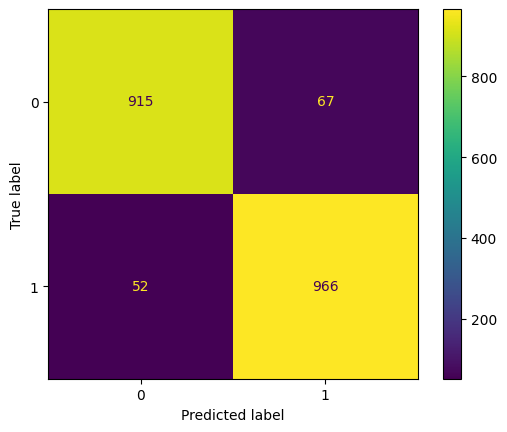

In [21]:
preds = trainer.predict(df_test)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Se construyó una matriz de confusión para analizar los aciertos y errores del modelo en ambas clases. Esto permite observar no solo el rendimiento global, sino también los tipos de errores que comete, como falsos positivos y falsos negativos, dando una visión más completa del comportamiento del modelo.

La matriz de confusión muestra que el modelo tiene un buen desempeño general, con una alta cantidad de predicciones correctas en ambas clases. Los errores se distribuyen de forma equilibrada, lo que indica que el modelo no presenta un sesgo fuerte hacia ninguna de las dos clases.

In [22]:
eval_acc = []
eval_f1 = []
epochs = []

for log in logs:
    if "eval_accuracy" in log:
        eval_acc.append(log["eval_accuracy"])
        eval_f1.append(log["eval_f1"])
        epochs.append(log["epoch"])

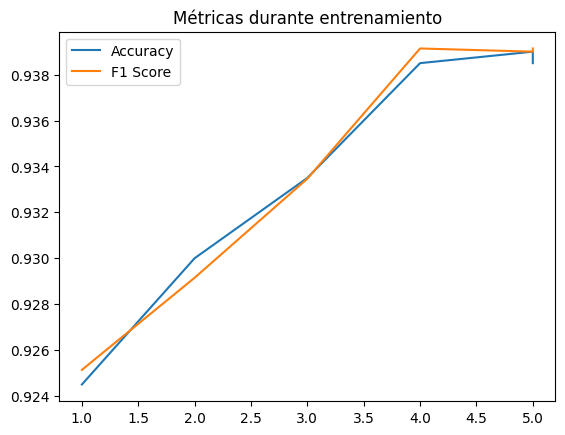

In [23]:
plt.plot(epochs, eval_acc, label="Accuracy")
plt.plot(epochs, eval_f1, label="F1 Score")
plt.legend()
plt.title("Métricas durante entrenamiento")
plt.show()

## <font color=  #003366> **Deetección de aspectos**</font>

In [24]:
aspect_keywords = {
    "calidad": ["quality", "design"],
    "precio": ["price", "cheap", "expensive", "worth"],
    "envio": ["shipping", "delivery", "arrive", "arrival", "took"]
}

## <font color=  #003366> **Análisis completo**</font>

In [25]:
def analizar_resena(texto):
    sentimiento, confianza = predecir_sentimiento(texto)

    return {
        "sentimiento_general": {
            "sentimiento": sentimiento,
            "confianza": round(confianza, 2)
        },
        "aspectos": analizar_aspectos(texto)
    }

Se definieron los aspectos principales que se quieren analizar dentro de las reseñas, como calidad, precio y envío. Para cada uno se estableció un conjunto de palabras clave relacionadas que permiten identificarlos dentro del texto.

Posteriormente, se creó una función que analiza cada reseña completa, primero obteniendo el sentimiento general mediante el modelo BERT, y después aplicando el análisis por aspectos para detectar opiniones específicas dentro del texto.

De esta forma, el sistema no solo clasifica la reseña como positiva o negativa, sino que también identifica qué partes del producto están siendo evaluadas y cómo se perciben, generando un análisis más detallado y útil.

## <font color=  #003366> **Prueba**</font>

In [26]:
review = "The quality of the product is excellent but the price is too high and the shipping was slow"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.75}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.92}, 'precio': {'sentimiento': 'negativo', 'confianza': 0.87}, 'envio': {'sentimiento': 'negativo', 'confianza': 0.84}}}


In [27]:
review = "Amazing product, great quality and fast shipping, totally worth the price"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.94}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.93}, 'envio': {'sentimiento': 'positivo', 'confianza': 0.93}, 'precio': {'sentimiento': 'positivo', 'confianza': 0.94}}}


In [28]:
review = "Very bad quality, overpriced and the delivery took forever"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'negativo', 'confianza': 0.94}, 'aspectos': {'calidad': {'sentimiento': 'negativo', 'confianza': 0.9}, 'precio': {'sentimiento': 'negativo', 'confianza': 0.92}, 'envio': {'sentimiento': 'positivo', 'confianza': 0.66}}}


In [29]:
review = "The price is cheap but the quality is terrible"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'negativo', 'confianza': 0.93}, 'aspectos': {'precio': {'sentimiento': 'negativo', 'confianza': 0.76}, 'calidad': {'sentimiento': 'negativo', 'confianza': 0.93}}}


In [30]:
review = "The quality is not good and the price is not worth it"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'negativo', 'confianza': 0.93}, 'aspectos': {'calidad': {'sentimiento': 'negativo', 'confianza': 0.91}, 'precio': {'sentimiento': 'negativo', 'confianza': 0.9}}}


In [31]:
review = "I love the design and quality, but I hate how long it took to arrive"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.84}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.87}, 'envio': {'sentimiento': 'negativo', 'confianza': 0.87}}}


In [32]:
review = "The price is reasonable and the shipping was okay"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.93}, 'aspectos': {'precio': {'sentimiento': 'positivo', 'confianza': 0.9}, 'envio': {'sentimiento': 'positivo', 'confianza': 0.86}}}


In [33]:
review = "Great, another product with amazing quality that broke in a day"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.93}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.93}}}


In [34]:
review = "Not good, not bad, I dont know"
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'negativo', 'confianza': 0.85}, 'aspectos': {}}


In [35]:
review = """The product has a really good build quality and feels durable, but the shipping took longer than expected and that was frustrating.
The price is fair, though, so I think it balances out overall."""
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.93}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.94}, 'envio': {'sentimiento': 'negativo', 'confianza': 0.77}, 'precio': {'sentimiento': 'positivo', 'confianza': 0.87}}}


In [36]:
review = """I’m quite happy with this purchase. The quality is solid and the product works just as described. Shipping was fast and the price seems reasonable for what you get."""
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'positivo', 'confianza': 0.95}, 'aspectos': {'calidad': {'sentimiento': 'positivo', 'confianza': 0.89}, 'precio': {'sentimiento': 'negativo', 'confianza': 0.57}}}


In [37]:
review = """This product was disappointing. The quality feels cheap and not very reliable, and the price is too high for something like this. Shipping was also slower than expected."""
print(analizar_resena(review))

{'sentimiento_general': {'sentimiento': 'negativo', 'confianza': 0.95}, 'aspectos': {'calidad': {'sentimiento': 'negativo', 'confianza': 0.93}, 'precio': {'sentimiento': 'negativo', 'confianza': 0.89}}}


## <font color=  #003366> **Guardar Modelo**</font>

In [38]:
model.save_pretrained("./modelo")
tokenizer.save_pretrained("./modelo")

('./modelo/tokenizer_config.json',
 './modelo/special_tokens_map.json',
 './modelo/vocab.txt',
 './modelo/added_tokens.json')

In [39]:
trainer.save_model("./modelo")

## <font color=  #003366> **Conclusión**</font>

El modelo desarrollado presenta un buen desempeño en tareas de clasificación de sentimientos y análisis por aspectos, sin embargo, existen varias limitaciones importantes que deben considerarse.
En primer lugar, tiene dificultades para interpretar correctamente el sarcasmo o la ironía, ya que el modelo BERT se basa principalmente en patrones lingüísticos directos y no siempre capta el significado implícito del contexto.
Además, el rendimiento puede verse afectado en reseñas muy largas o con múltiples ideas, ya que al dividir el texto en fragmentos puede perderse parte del contexto global, generando predicciones inconsistentes entre frases. Otro aspecto a considerar es que el modelo tiende a ser demasiado seguro en sus predicciones, incluso en casos ambiguos o neutros, debido a la naturaleza del entrenamiento binario.
Finalmente, el enfoque basado en palabras clave para la detección de aspectos también representa una limitación, ya que no siempre captura sinónimos o expresiones más complejas, lo que puede reducir la precisión del análisis en ciertos casos.